# Product Inventory Exploration

This notebook connects directly to MongoDB through MongoEngine, runs raw queries on products, and visualizes stock levels.

If imports fail, use your backend virtual environment as the notebook kernel and install required packages:

```bash
pip install mongoengine pandas matplotlib seaborn
```

In [2]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mongoengine import connect, disconnect

sns.set_theme(style="whitegrid")

In [3]:
# Ensure backend/python is on sys.path, even if Jupyter was started elsewhere.
def find_backend_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "manage.py").exists() and (candidate / "products").exists():
            return candidate
    raise RuntimeError("Could not locate backend/python root. Start Jupyter from backend/python or adjust this cell.")


BACKEND_ROOT = find_backend_root()
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

print(f"Using backend root: {BACKEND_ROOT}")

Using backend root: d:\Rippling Docs\Interneers\interneers-lab\backend\python


In [4]:
from products.models import ProductDocument

In [5]:
MONGO_SETTINGS = {
    "db": os.getenv("MONGO_DB_NAME", "interneers_lab"),
    "host": os.getenv("MONGO_HOST", "localhost"),
    "port": int(os.getenv("MONGO_PORT", "27019")),
    "username": os.getenv("MONGO_USERNAME", "root"),
    "password": os.getenv("MONGO_PASSWORD", "example"),
    "authentication_source": os.getenv("MONGO_AUTH_SOURCE", "admin"),
}

disconnect(alias="default")
connect(alias="default", **MONGO_SETTINGS)
print("Connected to MongoDB")

Connected to MongoDB


## Raw MongoEngine Queries

In [6]:
total_products = ProductDocument.objects.count()
low_stock_count = ProductDocument.objects(quantity__lt=5).count()

print(f"Total products: {total_products}")
print(f"Low stock (<5): {low_stock_count}")

Total products: 4
Low stock (<5): 3


In [7]:
print("Sample products:")
for product in ProductDocument.objects.order_by("id")[:10]:
    print(
        f"id={product.id}, name={product.name}, category={product.category}, "
        f"brand={product.brand}, qty={product.quantity}"
    )

Sample products:
id=2, name=iphone 16 pro max, category=mobile phones, brand=Apple, qty=4
id=3, name=iphone 16 pro max, category=mobile phones, brand=Apple, qty=4
id=4, name=Pillows, category=home accessories, brand=sleepwell, qty=2
id=5, name=Spider man T-shirt, category=clothing, brand=MARVEL, qty=20


In [8]:
low_stock_products = ProductDocument.objects(quantity__lt=5).order_by("quantity")
for product in low_stock_products:
    print(f"LOW STOCK -> id={product.id}, name={product.name}, qty={product.quantity}")

LOW STOCK -> id=4, name=Pillows, qty=2
LOW STOCK -> id=2, name=iphone 16 pro max, qty=4
LOW STOCK -> id=3, name=iphone 16 pro max, qty=4


## DataFrame View

In [9]:
rows = [product.to_dict() for product in ProductDocument.objects.order_by("id")]
df = pd.DataFrame(rows)

if df.empty:
    print("No products found in MongoDB.")
else:
    display(df.head())
    print(f"Rows: {len(df)}")

,id,name,description,category,price,brand,quantity,category_ids,created_at,updated_at
0,2,iphone 16 pro max,iphone,mobile phones,100000.0,Apple,4,[],2026-03-27 04:30:50.261,2026-03-27 04:30:50.261
1,3,iphone 16 pro max,iphone,mobile phones,100000.0,Apple,4,[],2026-03-27 04:31:27.318,2026-03-27 04:31:27.318
2,4,Pillows,pillows by SleepWell,home accessories,799.0,sleepwell,2,[],2026-03-27 04:34:38.737,2026-03-27 04:34:38.737
3,5,Spider man T-shirt,spider man merch by MARVEL,clothing,599.0,MARVEL,20,[],2026-03-27 04:37:37.586,2026-03-27 04:37:37.587


Rows: 4


## Visualizations

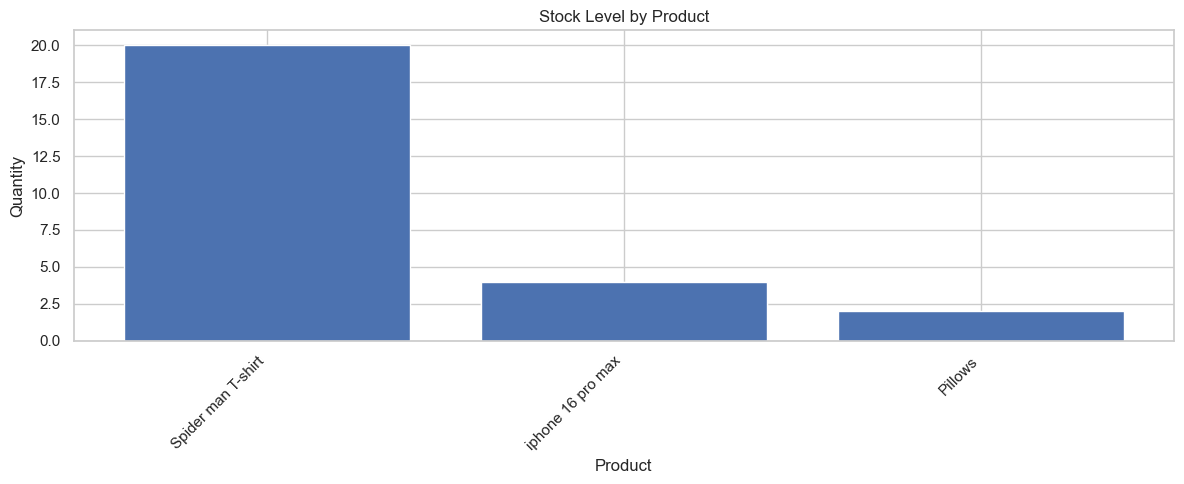

In [10]:
if not df.empty:
    stock_by_product = df[["name", "quantity"]].sort_values("quantity", ascending=False)

    plt.figure(figsize=(12, 5))
    plt.bar(stock_by_product["name"], stock_by_product["quantity"])
    plt.title("Stock Level by Product")
    plt.xlabel("Product")
    plt.ylabel("Quantity")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

C:\Users\kanis\AppData\Local\Temp\ipykernel_10928\1435870271.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stock_by_category, x="category", y="quantity", palette="Blues_d")


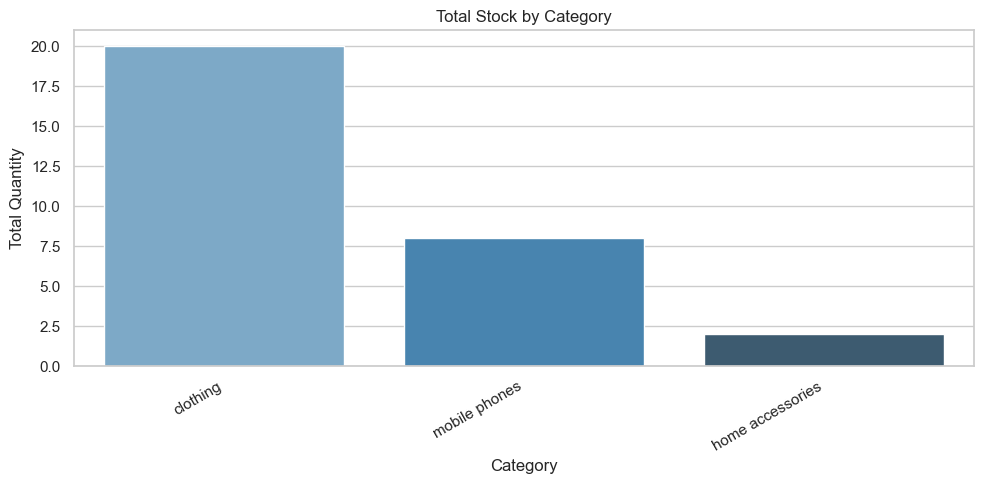

,category,quantity
0,clothing,20
2,mobile phones,8
1,home accessories,2


In [11]:
if not df.empty:
    stock_by_category = (
        df.groupby("category", as_index=False)["quantity"].sum().sort_values("quantity", ascending=False)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(data=stock_by_category, x="category", y="quantity", palette="Blues_d")
    plt.title("Total Stock by Category")
    plt.xlabel("Category")
    plt.ylabel("Total Quantity")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    display(stock_by_category)

In [12]:
# Run this when you are done with exploration.
disconnect(alias="default")
print("Disconnected from MongoDB")

Disconnected from MongoDB
